# Explore the Roman real-space 3x2pt data vector

This notebook calls the compiled Roman likelihood code (CosmoLike) from
Python to show how the galaxy–galaxy-lensing and clustering parts of the
**3x2pt data vector** respond to cosmology, baryonic feedback and numerical
settings, and evaluates the $\chi^2$ of the likelihood block of
[EXAMPLE_EVALUATE2.yaml](EXAMPLE_EVALUATE2.yaml) (`roman_real.combo_3x2pt`).
EXAMPLE_EVALUATE1 covers the cosmic-shear part.

"3x2pt" names the three two-point functions of two galaxy samples: the
positions of **lens** galaxies and the shapes of **source** galaxies. Each
sample is split into 8 tomographic bins by photometric redshift (photo-z: a
redshift estimated from broad-band colors); this example uses the same
redshift distributions, [data/example1.nz](data/example1.nz), for both.

| Block of the data vector | Bin pairs | Entries (15 angular bins each) |
| --- | --- | --- |
| Cosmic shear $\xi_+$, $\xi_-$ | 36 source pairs each | 540 + 540 |
| Galaxy–galaxy lensing $\gamma_t$ | 64 lens–source pairs minus 3 excluded | 915 |
| Galaxy clustering $w$ | 8 lens auto-correlations | 120 |
| Total | | 2,115, of which the mask keeps 1,950 |

Terms used throughout:

- **Data vector**: the ordered list of all predicted measurements above.
- **Mask**: a 0/1 list over the data vector that marks the entries entering
  the likelihood. In every $\gamma_t$ and $w$ row it removes the angular
  bins smaller than the angle that 1.5 Mpc/$h$ subtends at the lens bin's
  mean redshift (two to four bins), where the linear galaxy-bias model is
  not trusted.
- **Excluded pairs**: lens bin 7 with source bin 1 and lens bin 8 with
  source bins 1 and 2, counting from one; the sources lie in front of the
  lenses and carry almost no lensing signal.
- **Linear galaxy bias** $b_1$: lens galaxies trace matter as
  $\delta_g=b_1\,\delta_m$, with one value per lens bin.
- **Limber approximation**: a projected spectrum at multipole $\ell$
  receives power only from $k=(\ell+1/2)/\chi$ at each comoving distance
  $\chi$; it fails at low $\ell$ for narrow redshift bins, which matters
  for clustering.
- **NLA**: the nonlinear-alignment model of intrinsic alignments, the
  correlated orientations of galaxies that mimic a lensing signal.
- **Emulator**: a fast fitted replacement for an expensive calculation,
  here EuclidEmulator2 (EE2) for the nonlinear matter power spectrum.

Conventions: $\theta$ in arcmin, multipoles $\ell$ dimensionless. Arrays
count tomographic bins from 0 and figure labels from 1. Every wrapper call
runs CAMB once, which takes a few seconds, so the sweeps take minutes.
Compile the project and start Jupyter as described in the project's
[notebook instructions](README.md#notebooks).

## Set up the Python session

The first cell imports the libraries and sets the figure style; the second
puts CAMB, the shared notebook package and this project's wrappers on the
Python path.

- `ci` is `cosmolike_roman_real_interface`, the compiled C/C++ library of
  this project: the same code the Cobaya likelihood calls.
- `cnu` is `cosmolike_notebook_utils`, shared by every Cocoa project
  (`external_modules/code/cosmolike_core/cosmolike_notebook_utils`): the
  CAMB run, the data-vector and response-function plots, and the Fisher
  tools.
- `nw` is `cosmolike_roman_real_notebook_wrappers`, in this project's
  `interface/` folder: one Python function per observable, each returning
  NumPy arrays.
- `matplotlib.rcParams` is matplotlib's global style dictionary; the values
  set here apply to every later figure. `text.usetex = True` typesets the
  labels with LaTeX, which must be installed (the cell lists the packages).
- `OMP_NUM_THREADS` sets how many OpenMP threads the compiled loops use; it
  is set before the library is imported, so the OpenMP runtime reads it
  when it starts.
- Importing `euclidemu2` prints a notice that CLASS (`classy`) is missing.
  The EuclidEmulator2 boost used here does not need CLASS.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
# OpenMP threads of the compiled CosmoLike loops; set before the
# library is imported.
os.environ['OMP_NUM_THREADS'] = '8'
import matplotlib
import math
from matplotlib import pyplot as plt
import numpy as np
# euclidemu2 prints a notice that classy (CLASS) is missing; the
# EuclidEmulator2 boost used here does not need it.
import euclidemu2
import scipy
import cosmolike_roman_real_interface as ci
from getdist import IniFile
from scipy.interpolate import interp1d
import itertools
import iminuit
import functools
print(sys.version)
print(os.getcwd())

# Figure style: matplotlib.rcParams is the global style dictionary that
# every later figure reads.
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# usetex typesets every label with LaTeX. It needs the system packages
# texlive-latex-base, texlive-latex-extra, texlive-fonts-recommended,
# dvipng, ghostscript and cm-super; set it to False without them.
matplotlib.rcParams['text.usetex'] = True
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------

# Jupyter Notebook Display options
import IPython
IPython.display.display(IPython.display.HTML("<style>:root { --jp-notebook-max-width: 85% !important; }</style>"))
IPython.display.display(IPython.display.HTML("<style>div.output_scroll { height: 54em; }</style>"))


Classy could not be found in your system.
Here are some suggestions:

	 -Download the Class from class-code.net and install it
	  together with its wrapper classy (type 'make' instead of
	  'make class'
	 -If you know that Class is installed on your system
	  and yet classy could not be installed, try re-compiling
	  Class with just ''make'' instead of ''make class''
NOTICE: Even without classy you can still use EuclidEmulator2
        to emulate boost factors. You won't be able to compute
        full power spectra, though.


3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:18:52) [Clang 18.1.8 ]
/Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/roman_real


In [2]:
# Import CAMB. The path below is CAMB's Linux build folder; elsewhere
# Python finds the installed camb package, and the print shows which.
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/CAMB/build/lib.linux-x86_64-'+os.environ['PYTHON_VERSION'])
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

# Import the shared notebook utilities (cosmolike_core)
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/cosmolike_core')
import cosmolike_notebook_utils as cnu
print('Using cosmolike_notebook_utils installed at %s'%(os.path.dirname(cnu.__file__)))


# Import the project's notebook wrappers (projects/roman_real/interface):
# the probe, chi2, response, Fisher, and bfmt wrappers every notebook
# of this project shares
import cosmolike_roman_real_notebook_wrappers as nw
print('Using notebook wrappers installed at %s'%(nw.__file__))

Using CAMB 1.6.7 installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/.local/lib/python3.11/site-packages/camb
Using cosmolike_notebook_utils installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/external_modules/code/cosmolike_core/cosmolike_notebook_utils
Using notebook wrappers installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/roman_real/interface/cosmolike_roman_real_notebook_wrappers.py


## Choose the settings the wrappers read

`nw.configure` stores the values that differ between this project's
notebooks; every later wrapper call reads them:

- `lmax`: the largest multipole of the internal $C_\ell$ tables that the
  Legendre sums to real space use (100,000, as in EXAMPLE_EVALUATE2.yaml).
- `ntheta`, `theta_min_arcmin`, `theta_max_arcmin`: 15 logarithmic angular
  bins between 2.5 and 250 arcmin, as in the dataset file.
- `non_linear_emul`: the nonlinear matter power spectrum, 2 for CAMB's
  halofit (Takahashi version) and 1 for EuclidEmulator2.

The other names in the cell restate settings that the wrappers already
hold; nothing reads these notebook variables. The data-file and
intrinsic-alignment options (`path`, `data_file`, `ggl_exclude`,
`IA_model`, `IA_redshift_evolution`, `IA_code`) change through
`nw.configure` before `nw.init_cosmolike` runs, for example
`nw.configure(IA_model=1)` for TATT, the tidal-alignment and
tidal-torquing extension of NLA. `CLprobe` is an argument of
`nw.init_cosmolike`, and `CAMBAccuracyBoost` an argument of every wrapper
call.

In [3]:
CAMBAccuracyBoost = 1.0
non_linear_emul = 2
CLprobe="3x2pt"

path= "../../external_modules/data/roman_real"
data_file="example1.dataset"
ggl_exclude=[[6,0],[7,0],[7,1]]

IA_model = 0
IA_redshift_evolution = 3
IA_code = 0  # 0 = C FASTPT, 1 = Python FAST-PT (NLA always uses 0)

ntheta = 15
theta_min_arcmin = 2.5 
theta_max_arcmin = 250
lmax = 100000


# hand this notebook's yaml-mirroring values to the shared wrappers
nw.configure(lmax=lmax,
             ntheta=ntheta,
             theta_min_arcmin=theta_min_arcmin,
             theta_max_arcmin=theta_max_arcmin,
             non_linear_emul=non_linear_emul)

## The fiducial parameter point

The wrappers module defines one fiducial point, the
`sampler: evaluate: override` values of the example YAML files. This cell
imports the names so the sweeps below can build shifted vectors from them.
Every wrapper also uses them as defaults, and a call overrides any of them,
for example `nw.C_ss_tomo_limber(ell=ell, omegam=0.31)`.

| Name | Meaning | Fiducial |
| --- | --- | --- |
| `As_1e9` | $10^9 A_s$, amplitude of the primordial power spectrum | 2.1 |
| `ns` | scalar spectral index $n_s$ | 0.96605 |
| `H0` | Hubble constant in km/s/Mpc | 67.32 |
| `omegab`, `omegam` | $\Omega_b$ and $\Omega_m$ (matter includes massive neutrinos) | 0.04, 0.3 |
| `mnu` | sum of the neutrino masses in eV | 0.06 |
| `w`, `w0pwa` | dark-energy $w_0$ and $w_0+w_a$ | −1, −1 |
| `roman_A1_1`, `roman_A1_2` | NLA amplitude $A_{\rm IA}$ and its redshift index $\eta_{\rm IA}$ | 0.6, −1.5 |
| `roman_DZ_S1` … `roman_DZ_S8` | redshift shifts of the 8 source $n(z)$ (source photo-z) | 0 |
| `roman_M1` … `roman_M8` | multiplicative shear calibration $m$ of each source bin | 0 |
| `roman_DZ_L1` … `roman_DZ_L8` | redshift shifts of the 8 lens $n(z)$ (lens photo-z) | 0 |
| `roman_B1_1` … `roman_B1_8` | linear galaxy bias $b_1$ of each lens bin | 1.18 … 2.44 |
| `roman_PM1` … `roman_PM8` | point-mass amplitudes of $\gamma_t$, one per lens bin | 0 |

Galaxy–galaxy lensing reads every entry of the table; clustering reads the
cosmology, the lens photo-z shifts and the galaxy bias.

In [4]:
# The project fiducial point lives in the wrappers module
# (interface/cosmolike_roman_real_notebook_wrappers.py), shared by
# every notebook. The names are imported so the sweep cells below can
# build shifted vectors from them; override any value per call
# instead, e.g. nw.get_chi2(omegam=0.31).
from cosmolike_roman_real_notebook_wrappers import (
    As_1e9, ns, H0, omegab, omegam, mnu, w, w0pwa,
    roman_A1_1, roman_A1_2,
    roman_DZ_S1, roman_DZ_S2, roman_DZ_S3, roman_DZ_S4,
    roman_DZ_S5, roman_DZ_S6, roman_DZ_S7, roman_DZ_S8,
    roman_M1, roman_M2, roman_M3, roman_M4,
    roman_M5, roman_M6, roman_M7, roman_M8,
    roman_DZ_L1, roman_DZ_L2, roman_DZ_L3, roman_DZ_L4,
    roman_DZ_L5, roman_DZ_L6, roman_DZ_L7, roman_DZ_L8,
    roman_B1_1, roman_B1_2, roman_B1_3, roman_B1_4,
    roman_B1_5, roman_B1_6, roman_B1_7, roman_B1_8,
    roman_PM1, roman_PM2, roman_PM3, roman_PM4,
    roman_PM5, roman_PM6, roman_PM7, roman_PM8)

## What one wrapper call computes

Each `nw` function repeats the same four stages, so every call is
self-contained:

1. **CAMB.** `cnu.get_camb_cosmology` runs the Boltzmann code CAMB at the
   requested cosmology. It returns tables of $\ln P(k,z)$, linear and
   nonlinear ($k$ in $h/\mathrm{Mpc}$, $P$ in $(\mathrm{Mpc}/h)^3$), the
   growth factor, and the comoving distance $\chi(z)$ in Mpc/$h$.
2. **set_cosmology.** `ci.set_cosmology` copies these tables into the C
   library, which interpolates them during the projections.
3. **Nuisance setters.** `ci.set_nuisance_shear_calib`,
   `ci.set_nuisance_shear_photoz` and `ci.set_nuisance_ia` install the
   shear-calibration, source photo-z and intrinsic-alignment parameters;
   observables with lens galaxies also call `ci.set_nuisance_bias`,
   `ci.set_nuisance_clustering_photoz` and `ci.set_point_mass`.
   `ci.init_baryons_contamination` or `ci.reset_bary_struct` switches the
   hydrodynamical-simulation contamination on or off.
4. **Observable.** `ci.C_gs_tomo_limber`, `ci.w_gammat_tomo`, `ci.C_gg_tomo`,
   `ci.w_gg_tomo` or another function evaluates the requested quantity.
   Galaxy–galaxy lensing needs the shear and the clustering nuisances;
   clustering needs only the latter.

The C library keeps this state in global variables: a spectrum call reads
whatever was set last. Rebuilding everything in every call makes each cell
independent of the cells run before it, at the cost of one CAMB run per
call. The code cells below only record where the functions used in
this notebook are defined; they execute nothing. The comment in the
first one notes that the redshift grid of the comoving distances grows
with the CAMB boost.

In [5]:
# get_camb_cosmology lives in cosmolike_core, shared by every project's
# notebooks; call it as cnu.get_camb_cosmology (imported above). It
# scales the chi(z) node count with the CAMB boost (1625 nodes at
# boost 1). The nw wrappers hand it kmax explicitly; each wrapper's
# signature gives its default.

In [6]:
# C_gs_tomo_limber lives in this project's interface/
# (cosmolike_roman_real_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.C_gs_tomo_limber.

In [7]:
# C_gg_tomo lives in this project's interface/
# (cosmolike_roman_real_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.C_gg_tomo.

In [8]:
# gamma_t lives in this project's interface/
# (cosmolike_roman_real_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.gamma_t.

In [9]:
# w_theta lives in this project's interface/
# (cosmolike_roman_real_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.w_theta.

## How the shared plotting functions draw the 3x2pt panels

- `cnu.plot_C_gs_tomo_limber` and `cnu.plot_gammat_tomo_limber` draw one
  panel per lens–source pair: one row per source bin and one column per lens
  bin, 64 panels labeled (lens, source). The three excluded pairs arrive as
  arrays of zeros and appear as empty panels marked "excluded".
- `cnu.plot_C_gg_tomo` and `cnu.plot_wtheta_tomo` draw one row of 8 panels,
  the auto-correlation of each lens bin, labeled (1) … (8).
- **Without a reference** each panel shows the quantity on a log axis:
  $|C_\ell^{gs}|$, $|\gamma_t|$, $C_\ell^{gg}$ or $|w|$; here `ylim`
  multiplies each panel's minimum and maximum. Galaxy–galaxy lensing can
  change sign, so its absolute value is drawn, and a sign change appears as
  a sharp dip. With `rescale=1` each panel is multiplied by its own power of
  ten, printed inside it as $\alpha$; `ydecades=4` keeps the shared range
  within four decades of its top, so the dips do not compress the other
  panels.
- **With a reference** each panel shows the fractional difference
  $X/X_{\rm ref}-1$, and `ylim` gives the band around 1:
  `ylim=(0.981, 1.019)` draws ±1.9%.
- Arrays count bins from 0 and labels from 1: the panel labeled (2,3) draws
  lens index 1 and source index 2, `C_gs[:, 1, 2]`.

The four code cells below record where the plotting functions are defined;
`help(cnu.plot_gammat_tomo_limber)` prints every option.

In [10]:
# plot_C_gs_tomo_limber lives in cosmolike_core (shared); call it as
# cnu.plot_C_gs_tomo_limber (imported above). Its panel grid has one
# row per source bin and one column per lens bin, for any lens and
# source bin counts.


In [11]:
# plot_C_gg_tomo lives in cosmolike_core (shared); call it as
# cnu.plot_C_gg_tomo (imported above)


In [12]:
# plot_gammat_tomo_limber lives in cosmolike_core (shared); call it
# as cnu.plot_gammat_tomo_limber (imported above). Its panel grid has
# one row per source bin and one column per lens bin, for any lens
# and source bin counts; thetashow sets the x range.


In [13]:
# plot_wtheta_tomo lives in cosmolike_core (shared); call it as
# cnu.plot_wtheta_tomo (imported above)


## Initialize CosmoLike

`nw.init_cosmolike` reads [data/example1.dataset](data/example1.dataset),
a short text file that names the redshift distributions (one file,
`example1.nz`, serves lenses and sources), the covariance, the mask and
the data vector, and gives the angular binning. It then installs the excluded
galaxy–galaxy-lensing pairs, the 8 lens and 8 source $n(z)$ tables, the
angular binning and the intrinsic-alignment model (NLA with power-law
redshift evolution). Called without arguments it loads neither covariance
nor data, which plotting does not need. The printed lines list the three
lens–source pairs removed from $\gamma_t$, counted from 0: `L6-S0` is lens
bin 7 with source bin 1 counting from one. `allsims` is the HDF5 file of
hydrodynamical-simulation power spectra used in the baryon sections.

In [14]:
# Init Cosmolike (the full sequence lives in nw.init_cosmolike)
ini = nw.init_cosmolike()
allsims = nw.allsims

[2026-10-01 14:21:23.510] [info] init_ntomo_powerspectra: GGL pair L6-S0 is excluded
[2026-10-01 14:21:23.510] [info] init_ntomo_powerspectra: GGL pair L7-S0 is excluded
[2026-10-01 14:21:23.510] [info] init_ntomo_powerspectra: GGL pair L7-S1 is excluded


## How cosmology changes the galaxy–galaxy-lensing spectrum $C_\ell^{gs}$

$C_\ell^{gs}$ correlates the positions of lens bin $i$ with the shear of
source bin $j$. In the Limber approximation
$$C^{gs}_{ij}(\ell)=\int d\chi\,
\frac{b_i\,n^{\rm lens}_i(\chi)\,q_j(\chi)}{\chi^2}\,
P_{\rm NL}\!\left(\frac{\ell+1/2}{\chi},\,z(\chi)\right),$$
with $b_i$ the linear bias, $n^{\rm lens}_i$ the lens distribution in
comoving distance and $q_j$ the lensing efficiency of the source bin, plus
an intrinsic-alignment term in which the source's alignment kernel replaces
$q_j$. The signal is large when the lenses sit in front of the sources.
When the source bin lies in front of the lens bin, only the overlapping
tails of the two distributions contribute, and the alignment term can cancel
the lensing term: there $|C_\ell^{gs}|$ dips where the sign changes.
`nw.C_gs_tomo_limber(ell=...)` returns an array of shape (n_ell, 8, 8),
indexed [ell, lens, source].

The first figure varies $\Omega_m$ from 0.20 to 0.38 and draws the absolute
spectra, rescaled panel by panel, for $\ell$ from 25 to 2,497. The second
varies $n_s$ from 0.85 to 1.09 and divides by the fiducial spectrum, in a
band from −23% to +32.5%.

In [15]:
ell = np.arange(25., 2500., 3.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(0.2, 0.4, 0.02)
C_gs = []
for x in param:
    C_gs.append(nw.C_gs_tomo_limber(ell=ell, omegam=x))

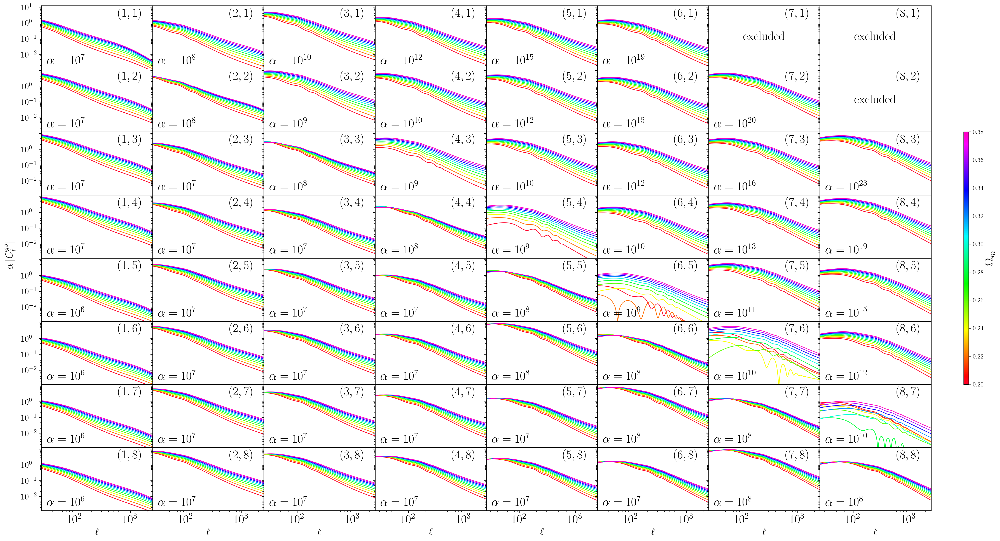

In [16]:
cnu.plot_C_gs_tomo_limber(ell=ell,
                          C_gs = np.abs(C_gs),
                          param = param,
                          colorbarlabel = "$\Omega_m$",
                          bintextpos = [0.8, 0.875],
                          ylim = [0.75,1.3],
                          lmin = ell[0],
                          lmax = ell[len(ell)-1],
                          figsize = (32, 15),
                          bintextsize = 20,
                          yaxislabelsize = 17,
                          yaxisticklabelsize = 14,
                          xaxisticklabelsize = 20,
                          rescale=1,
                          ydecades=4)

In [17]:
ell = np.arange(25., 2500., 3.) # Make sure arange are with float numbers (otherwise there are aliasing problems)
param = np.arange(0.85, 1.1, 0.02)
C_gs = []
for x in param:
    C_gs.append(nw.C_gs_tomo_limber(ell=ell, ns=x))

# Plot the Ratio over ref cosmology
ref = nw.C_gs_tomo_limber(ell=ell)

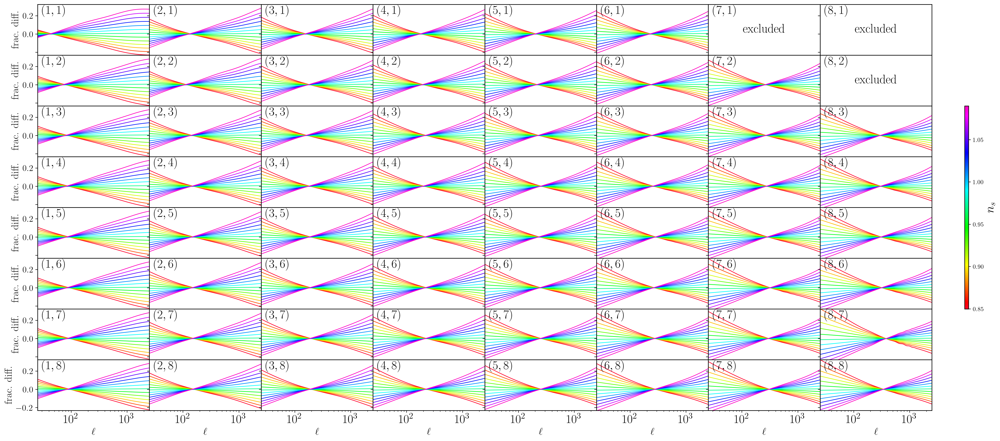

In [18]:
cnu.plot_C_gs_tomo_limber(ell=ell,
                          C_gs=C_gs,
                          C_gs_ref=ref,
                          param=param,
                          colorbarlabel="$n_s$",
                          bintextpos = [0.15, 0.875],
                          ylim = [0.77,1.325],
                          lmin=ell[0],
                          lmax=ell[len(ell)-1],
                          figsize = (32, 12),
                          bintextsize = 20,
                          yaxislabelsize = 17,
                          yaxisticklabelsize = 14,
                          xaxisticklabelsize = 20)

## How $\Omega_m$ changes the tangential shear $\gamma_t(\theta)$

The tangential shear of source bin $j$ around the galaxies of lens bin $i$
is the real-space counterpart of $C_\ell^{gs}$; in the flat-sky limit
$$\gamma_t^{ij}(\theta)=\frac{1}{2\pi}\int_0^\infty d\ell\,\ell\,
J_2(\ell\theta)\,C^{gs}_{ij}(\ell).$$
CosmoLike evaluates the full-sky Legendre sum, averaged over each angular
bin, and adds the point-mass term, which is zero at the fiducial point.
`nw.gamma_t()` returns the 15 bin centers in arcmin and an array of shape
(15, 8, 8), indexed [theta, lens, source]. The figure shows $|\gamma_t|$
for $\Omega_m$ from 0.20 to 0.38, rescaled panel by panel.

In [19]:
param = np.arange(0.2, 0.4, 0.02)   
gammat_theta = []
for x in param:
    gammat_theta.append(nw.gamma_t(omegam = x))

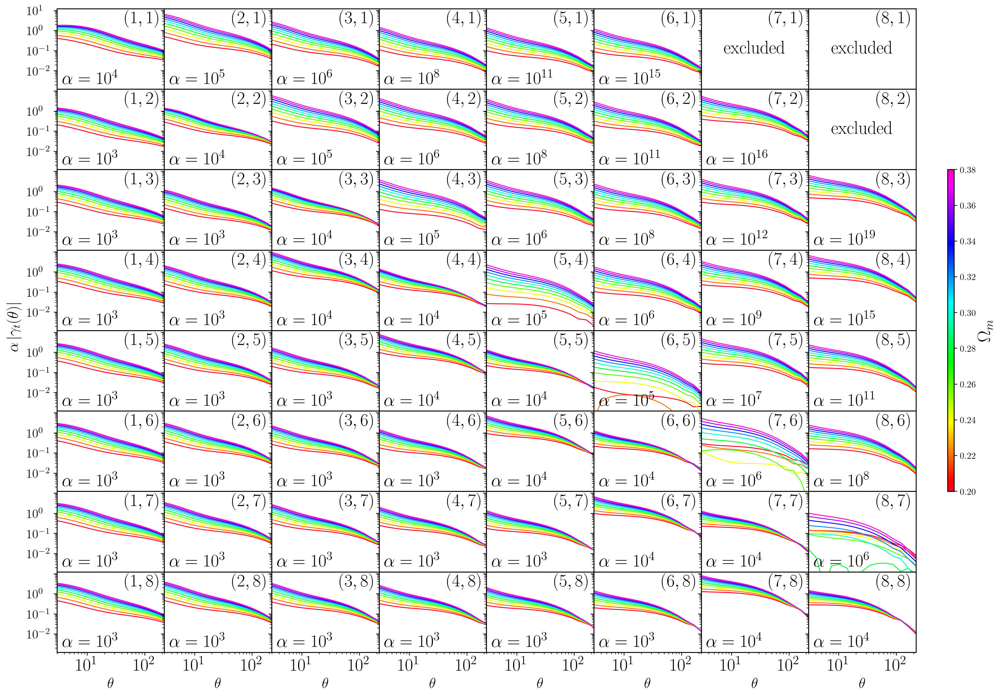

In [20]:
cnu.plot_gammat_tomo_limber(theta_gammat = gammat_theta,
                            gammat_ref = None,
                            param = param,
                            colorbarlabel = "$\Omega_m$",
                            bintextpos = [0.8, 0.875],
                            ylim = [0.75,1.3],
                            figsize = (21, 13),
                            bintextsize = 20,
                            yaxislabelsize = 17,
                            yaxisticklabelsize = 14,
                            xaxisticklabelsize = 20,
                            rescale=1,
                            ydecades=4)

## Change the angular binning of $\gamma_t$ without restarting the kernel

`nw.gamma_t(ntheta=...)` re-runs `ci.init_binning` before each evaluation,
here with 9, 12, 17 and 44 logarithmic bins over the same 2.5–250 arcmin
range. This is a real test: CosmoLike precomputes the bin-averaged Legendre
weights of the current binning and keeps them in static C variables, which
persist between calls, so a stale cache would pair the new bins with old
weights. Each binning is drawn with its own marker, and the points of all
binnings should trace nearly the same curve.

In [21]:
nthetas=[9, 12, 17, 44]
gammat_theta = []
for x in nthetas:
    gammat_theta.append(nw.gamma_t(ntheta=x))

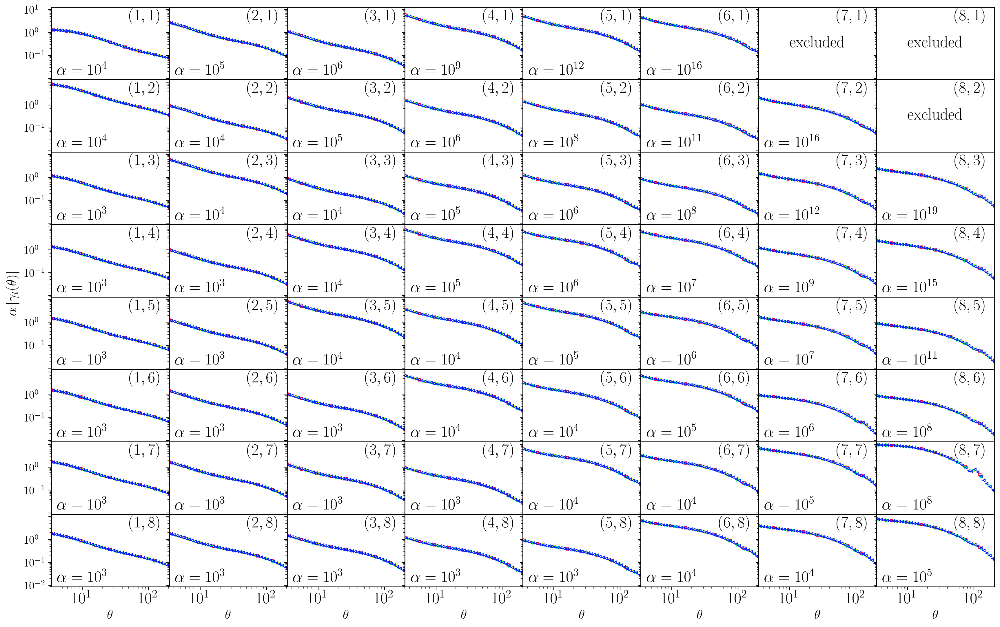

In [22]:
cnu.plot_gammat_tomo_limber(theta_gammat = gammat_theta,
                            marker=['s', 'o', ">", "<"],
                            ylim = [0.75,1.3],
                            bintextpos = [0.8, 0.875],
                            figsize = (21, 13),
                            bintextsize = 20,
                            yaxislabelsize = 17,
                            yaxisticklabelsize = 14,
                            xaxisticklabelsize = 20,
                            rescale=1,
                            ydecades=4)

## Baryonic feedback in $C_\ell^{gs}$ and $\gamma_t$

Feedback from active galactic nuclei and supernovae pushes gas out of halos
and suppresses the matter power spectrum on small scales. `baryon_sims=<name>`
multiplies the nonlinear $P(k,z)$ by the ratio $P_{\rm hydro}/P_{\rm DMO}$
measured in one hydrodynamical simulation (DMO: dark-matter only), read from
`allsims`, [data/baryons_logPkR.h5](data/baryons_logPkR.h5). The nine
scenarios are IllustrisTNG-100 (`TNG100-1`), Horizon-AGN (`HzAGN-1`), MassiveBlack-II
(`mb2-1`), Illustris (`illustris-1`), EAGLE (`eagle-1`), cosmo-OWLS AGN with
heating temperatures $\log_{10}(T/\mathrm{K})=8.0$, 8.5 and 8.7
(`owls_AGN-1`, `-2`, `-3`) and BAHAMAS with $\log_{10}(T/\mathrm{K})=7.6$
(`BAHAMAS-2`).

Each panel shows the contaminated prediction relative to the DMO one: the
$C_\ell^{gs}$ figure for $\ell$ from 50 to 7,493, the $\gamma_t$ figure in 40
angular bins. The legends name the simulations.

In [23]:
ell = np.arange(3., 7500., 10.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = ("TNG100-1", "HzAGN-1", "mb2-1", "illustris-1", "eagle-1", "owls_AGN-1", "owls_AGN-2", "owls_AGN-3", "BAHAMAS-2")
    
C_gs = []
for x in param:
    C_gs.append(nw.C_gs_tomo_limber(ell=ell,baryon_sims=x))
    
# Plot the Ratio over ref cosmology
C_gs_ref = nw.C_gs_tomo_limber(ell=ell)

gammat_theta = []
for x in param:
    gammat_theta.append(nw.gamma_t(baryon_sims=x, ntheta=40, AccuracyBoost=1.0))
gammat_theta_ref = nw.gamma_t(ntheta=40, AccuracyBoost=1.0)

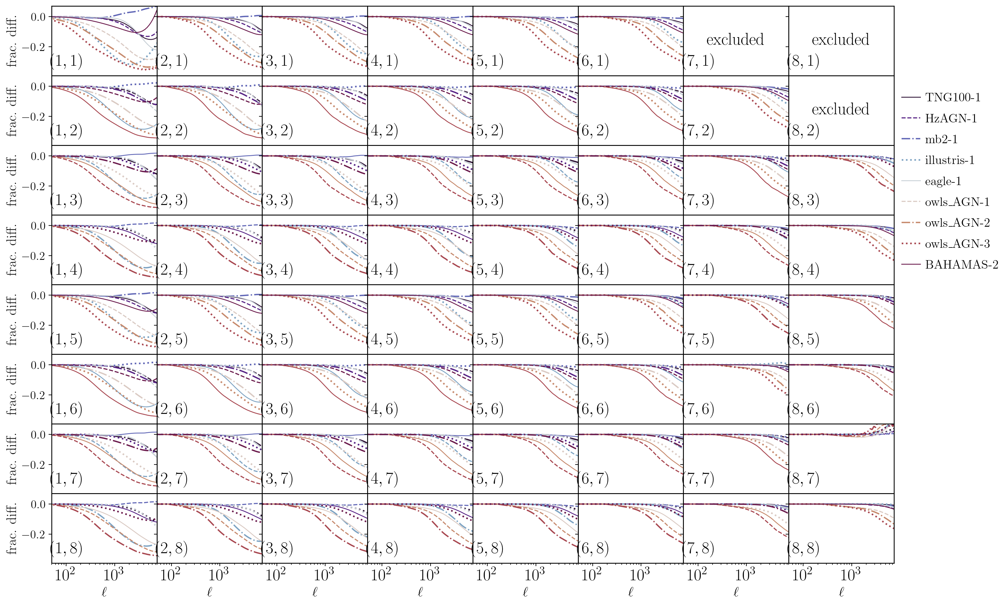

In [24]:
matplotlib.rcParams['legend.fontsize'] = 15
cnu.plot_C_gs_tomo_limber(ell=ell,
                          C_gs=C_gs,
                          C_gs_ref=C_gs_ref,
                          lmin=50,
                          lmax=ell[len(ell)-1],
                          cmap="twilight_shifted",
                          bintextpos = [0.15, 0.2],
                          ylim = [0.61,1.07],
                          legend = param,
                          legendloc=(0.9,0.55),
                          linewidth=[1.0, 1.3, 1.6, 1.9],
                          linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                          figsize = (18, 12),
                          bintextsize = 20,
                          yaxislabelsize = 17,
                          yaxisticklabelsize = 14,
                          xaxisticklabelsize = 20)

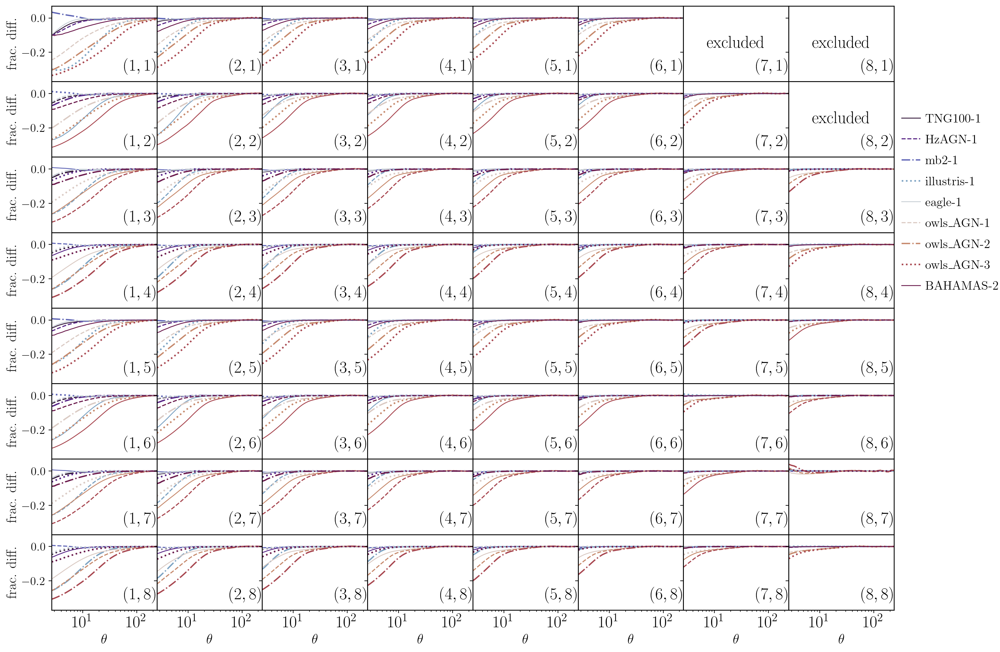

In [25]:
cnu.plot_gammat_tomo_limber(theta_gammat=gammat_theta,
                            gammat_ref=gammat_theta_ref,
                            cmap="twilight_shifted",
                            bintextpos = [0.85, 0.2],
                            ylim = [0.63,1.07],
                            legend = param,
                            legendloc=(0.9,0.55),
                            linewidth=[1.0, 1.3, 1.6, 1.9],
                            linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                            figsize = (18, 13),
                            bintextsize = 20,
                            yaxislabelsize = 17,
                            yaxisticklabelsize = 14,
                            xaxisticklabelsize = 20)

## Check how CAMB and CosmoLike accuracy settings change $C_\ell^{gs}$ and $\gamma_t$

The wrappers accept four accuracy arguments: `CLAccuracyBoost` refines
CosmoLike's interpolation tables and grids, `CLIntegrationAccuracy` sets its
integer quadrature level (the wrappers add $|3\,(\mathrm{CLAccuracyBoost}-1)|$
to it), `CAMBAccuracyBoost` raises CAMB's accuracy, and `AccuracyBoost`
moves both codes. Here one sweep variable $x$, from 0 to 5.5, raises them
together: `CAMBAccuracyBoost` $=1+x/3$, `CLAccuracyBoost` $=1+x$ and
`CLIntegrationAccuracy` $=\lfloor x\rfloor$. Each panel shows the result
relative to the default settings ($x=0$) in a ±1.9% band; the colorbar
shows $x$.

The text cell after the $C_\ell^{gs}$ figure explains the percent-level
shifts in pairs whose source bin lies in front of the lens bin: there
$C_\ell^{gs}$ is a small residual of cancelling lensing and alignment terms,
so a small absolute numerical change becomes a large fractional one. The
likelihood weighs absolute differences against the covariance, and the
project tests measure the resulting $\Delta\chi^2$.

In [26]:
ell = np.arange(10., 8500., 30.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)

param = np.arange(0,6.0,0.5)

C_gs = []
for x in param:
    C_gs.append(nw.C_gs_tomo_limber(ell=ell, AccuracyBoost=1.0,CAMBAccuracyBoost=1.+x/3.,CLAccuracyBoost=1+x,CLIntegrationAccuracy=int(x)))
    
# Plot the Ratio over ref cosmology
C_gs_ref = nw.C_gs_tomo_limber(ell = ell,
                            AccuracyBoost = 1.0,
                            CAMBAccuracyBoost = 1.,
                            CLAccuracyBoost=1,CLIntegrationAccuracy=0)

gammat_theta = []
for x in param:
    gammat_theta.append(nw.gamma_t(ntheta = 40,
                        AccuracyBoost = 1.0,
                        CAMBAccuracyBoost = 1. + x/3.,
                        CLAccuracyBoost = 1+x,
                        CLIntegrationAccuracy=int(x))
                       )
gammat_theta_ref = nw.gamma_t(ntheta = 40,
                           AccuracyBoost = 1.0,
                           CAMBAccuracyBoost = 1.,
                           CLAccuracyBoost = 1,
                           CLIntegrationAccuracy = 0)

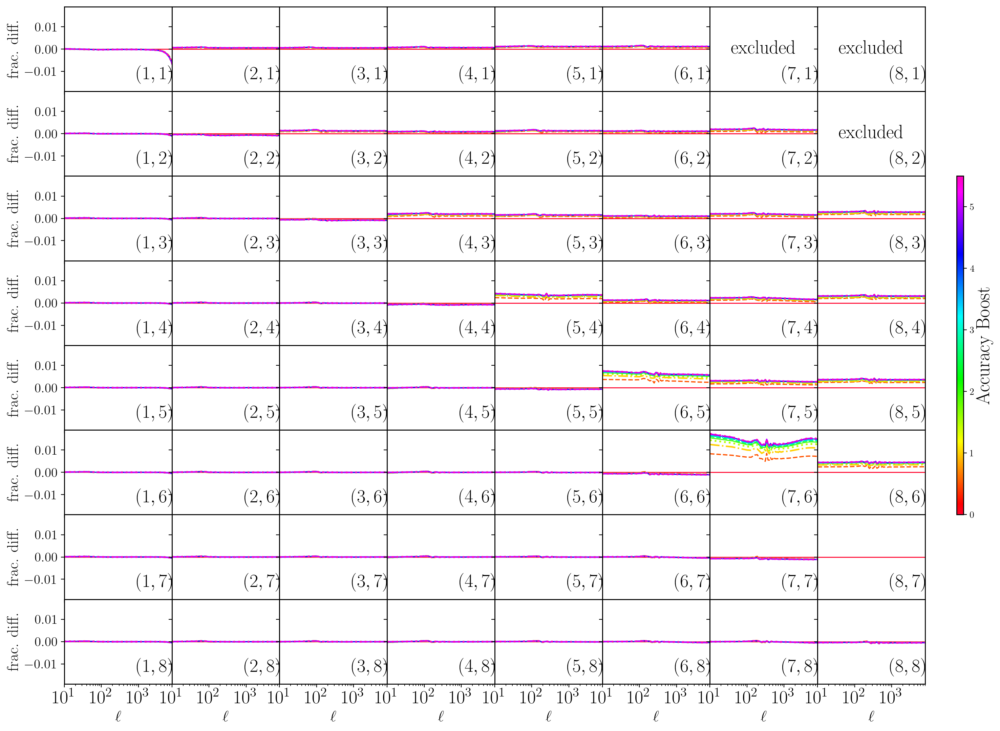

In [27]:
cnu.plot_C_gs_tomo_limber(ell = ell,
                          C_gs = C_gs,
                          C_gs_ref = C_gs_ref,
                          param = param,
                          lmin = 10,
                          lmax = 8000,
                          ylim = (0.981,1.019),
                          bintextpos = [0.85, 0.2],
                          colorbarlabel="Accuracy Boost",
                          linewidth=[1.0, 1.3, 1.6, 1.9],
                          linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                          figsize = (20, 13),
                          bintextsize = 20,
                          yaxislabelsize = 17,
                          yaxisticklabelsize = 14,
                          xaxisticklabelsize = 20,
                          rescale=1,
                          ydecades=4)

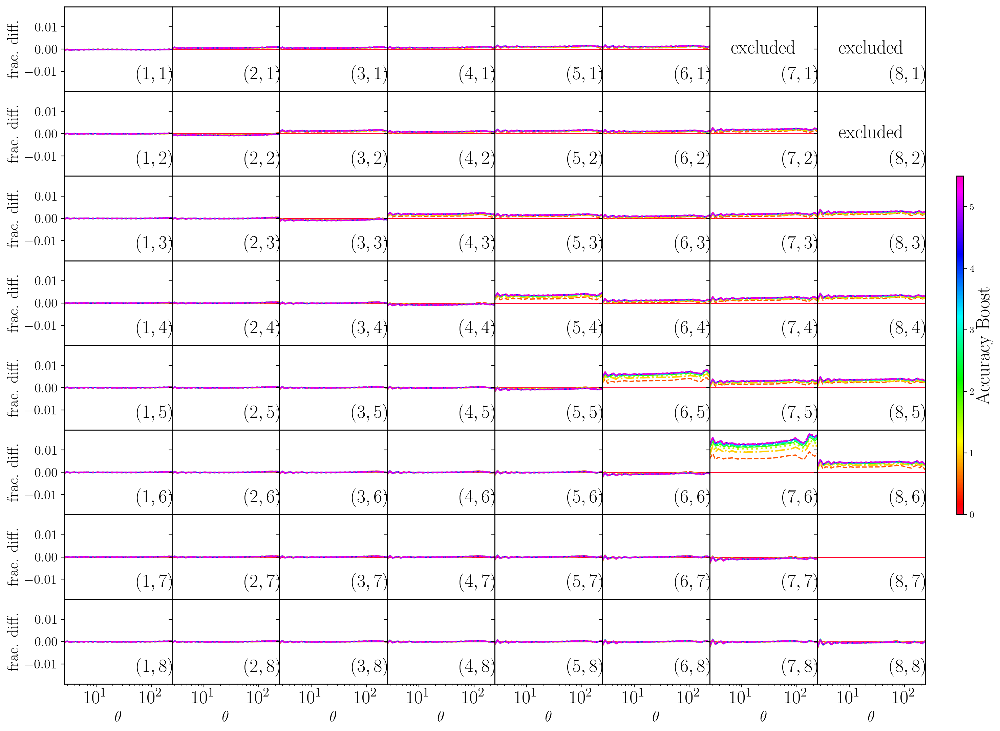

In [28]:
cnu.plot_gammat_tomo_limber(theta_gammat = gammat_theta,
                            gammat_ref = gammat_theta_ref,
                            bintextpos = [0.85, 0.2],
                            ylim = (0.981,1.019),
                            param = param,
                            legendloc = (0.9,0.55),
                            colorbarlabel="Accuracy Boost",
                            linewidth=[1.0, 1.3, 1.6, 1.9],
                            linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                            figsize = (20, 13),
                            bintextsize = 20,
                            yaxislabelsize = 17,
                            yaxisticklabelsize = 14,
                            xaxisticklabelsize = 20,
                            rescale=1,
                            ydecades=4)

## How $\Omega_m$ changes the clustering spectrum $C_\ell^{gg}$, with and without the Limber approximation

For the auto-correlation of lens bin $i$ the Limber approximation gives
$$C^{gg}_{ii}(\ell)=\int d\chi\,\frac{[b_i\,n_i(\chi)]^2}{\chi^2}\,
P_{\rm NL}\!\left(\frac{\ell+1/2}{\chi},\,z(\chi)\right).$$
It replaces the exact projection, which integrates spherical Bessel
functions $j_\ell(k\chi)$ along the line of sight, and fails at low $\ell$
when the redshift bins are narrow. `nw.C_gg_tomo(ell, limber=1)` returns the
Limber result; `limber=0` computes the exact projection (with FFTLog) below
a switching multipole and the Limber result above it. In the labels of
these figures NL means non-Limber, not nonlinear.

The first pair of figures varies $\Omega_m$ from 0.20 to 0.38 and draws
both versions, rescaled panel by panel, for $\ell$ from 3 to 2,499. The
second draws their ratio $C_\ell^{\rm NL}/C_\ell^{\rm L}$ itself, not a
fractional difference, for $\ell$ from 3 to 120. The division can warn
about invalid values: entries that vanish in both arrays, which the panels
do not draw, give 0/0.

In [29]:
ell = np.arange(3., 2500., 3.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(0.2, 0.4, 0.02)
C_gg_L = []
C_gg_NL = []
ratio = []
for x in param:
    tmp1 = nw.C_gg_tomo(ell=ell, limber=1, omegam=x)
    tmp2 = nw.C_gg_tomo(ell=ell, limber=0, omegam=x)
    C_gg_L.append(tmp1)
    C_gg_NL.append(tmp2)

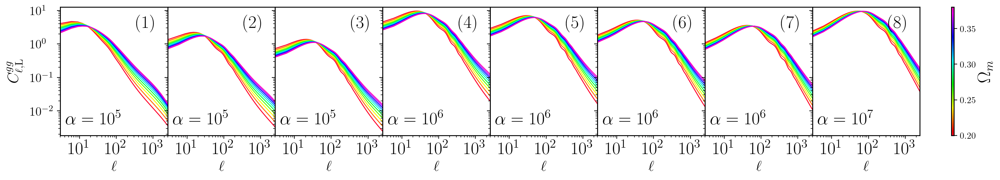

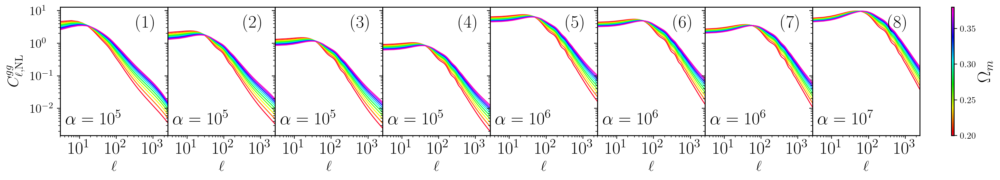

In [30]:
cnu.plot_C_gg_tomo(ell = ell,
                   C_gg = C_gg_L,
                   param = param,
                   colorbarlabel = "$\Omega_m$",
                   bintextpos = [0.8, 0.875],
                   ylim = [0.75,1.3],
                   lmin = ell[0],
                   lmax = ell[len(ell)-1],
                   overwriteylabel = "$C_{\ell,{\\rm L}}^{gg}$",
                   figsize = (21, 13./5),
                   bintextsize = 20,
                   yaxislabelsize = 17,
                   yaxisticklabelsize = 14,
                   xaxisticklabelsize = 20,
                   rescale=1,
                   ydecades=4)
cnu.plot_C_gg_tomo(ell = ell,
                   C_gg = C_gg_NL,
                   param = param,
                   colorbarlabel = "$\Omega_m$",
                   bintextpos = [0.8, 0.875],
                   ylim = [0.75,1.3],
                   lmin = ell[0],
                   lmax = ell[len(ell)-1],
                   overwriteylabel = "$C_{\ell,{\\rm NL}}^{gg}$",
                   figsize = (21, 13./5),
                   bintextsize = 20,
                   yaxislabelsize = 17,
                   yaxisticklabelsize = 14,
                   xaxisticklabelsize = 20,
                   rescale=1,
                   ydecades=4)

In [31]:
ell = np.arange(3., 250., 1.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(0.2, 0.4, 0.02)
ratio = []
for x in param:
    tmp1 = nw.C_gg_tomo(ell=ell, limber=1, omegam=x)
    tmp2 = nw.C_gg_tomo(ell=ell, limber=0, omegam=x)
    # non-Limber over Limber, plotted as the ratio itself
    ratio.append(tmp2/tmp1)

/var/folders/8m/fbnlt6rs00g8g5nshfw27mfw0000gn/T/ipykernel_76170/4250613529.py:7: RuntimeWarning: invalid value encountered in divide
  ratio.append(tmp2/tmp1)


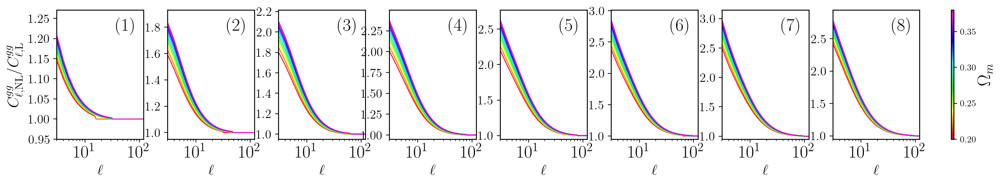

In [32]:
cnu.plot_C_gg_tomo(ell=ell,
                   C_gg=ratio,
                   param = param,
                   colorbarlabel = "$\Omega_m$",
                   bintextpos = [0.8, 0.875],
                   ylim = [0.95,1.05],
                   lmin = 3,
                   lmax = 120,
                   forcelinearyscale = True,
                   overwriteylabel = "$C_{\ell,{\\rm NL}}^{gg}/C_{\ell,{\\rm L}}^{gg}$",
                   forcelinearxscale = False,
                   marker = None,
                   figsize = (21, 13./5),
                   bintextsize = 20,
                   yaxislabelsize = 17,
                   yaxisticklabelsize = 14,
                   xaxisticklabelsize = 20)

## How $\Omega_m$ changes the angular clustering $w(\theta)$

$w_i(\theta)$, the angular correlation function of lens bin $i$, is the
real-space counterpart of $C_\ell^{gg}$; in the flat-sky limit
$w(\theta)=\frac{1}{2\pi}\int d\ell\,\ell\,J_0(\ell\theta)\,C_\ell^{gg}$,
which CosmoLike evaluates as a full-sky Legendre sum averaged over each
angular bin. `nw.w_theta()` returns the bin centers in arcmin and an array of
shape (15, 8, 8) whose diagonal the panels draw. The figure shows $|w|$ for
$\Omega_m$ from 0.20 to 0.38, rescaled panel by panel.

In [33]:
param = np.arange(0.2, 0.4, 0.02)   
wtheta_theta = []
for x in param:
    wtheta_theta.append(nw.w_theta(omegam = x))

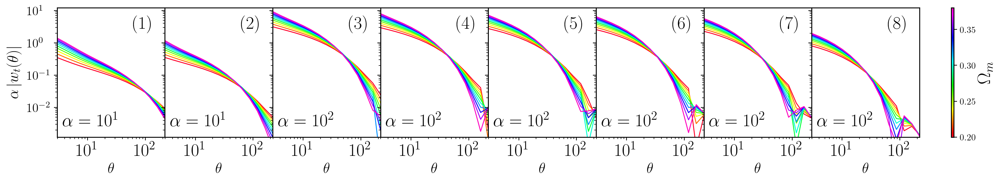

In [34]:
cnu.plot_wtheta_tomo(theta_wtheta = wtheta_theta,
                     theta_wtheta_ref = None,
                     param = param,
                     colorbarlabel = "$\Omega_m$",
                     bintextpos = [0.8, 0.875],
                     ylim = [0.75,1.3],
                     figsize = (21, 13./5),
                     bintextsize = 20,
                     yaxislabelsize = 17,
                     yaxisticklabelsize = 14,
                     xaxisticklabelsize = 20,
                     rescale=1,
                     ydecades=4)

## Change the angular binning of $w(\theta)$ without restarting the kernel

The same test as for $\gamma_t$: `nw.w_theta(ntheta=...)` re-bins with 9,
12, 17 and 44 bins, and the cached bin-averaged Legendre weights must follow
the new binning.

In [35]:
nthetas=[9, 12, 17, 44]
wtheta_theta = []
for x in nthetas:
    wtheta_theta.append(nw.w_theta(ntheta=x))

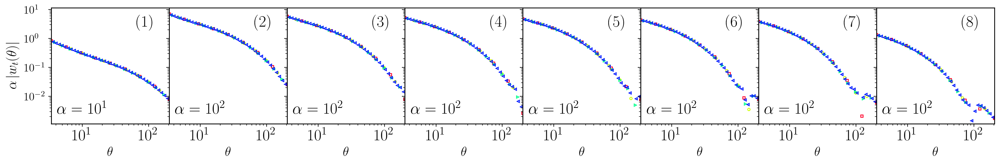

In [36]:
cnu.plot_wtheta_tomo(theta_wtheta = wtheta_theta,
                     marker = ['s', 'o', ">", "<"],
                     ylim = [0.75,1.3],
                     bintextpos = [0.8, 0.875],
                     figsize = (21, 13./5),
                     bintextsize = 20,
                     yaxislabelsize = 17,
                     yaxisticklabelsize = 14,
                     xaxisticklabelsize = 20,
                     rescale=1,
                     ydecades=4)

## Baryonic feedback in $C_\ell^{gg}$ and $w(\theta)$

The same nine hydrodynamical scenarios, now for the non-Limber $C_\ell^{gg}$
($\ell$ from 50 to 7,493) and for $w(\theta)$ in 40 angular bins, each
relative to the dark-matter-only prediction.

In [37]:
ell = np.arange(3., 7500., 10.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = ("TNG100-1", "HzAGN-1", "mb2-1", "illustris-1", "eagle-1", "owls_AGN-1", "owls_AGN-2", "owls_AGN-3", "BAHAMAS-2")
    
C_gg = []
for x in param:
    C_gg.append(nw.C_gg_tomo(ell=ell,limber=False,baryon_sims=x))
    
# Plot the Ratio over ref cosmology
C_gg_ref = nw.C_gg_tomo(ell=ell,limber=False)

wtheta_theta = []
for x in param:
    wtheta_theta.append(nw.w_theta(baryon_sims=x, ntheta=40, AccuracyBoost=1.0))
wtheta_theta_ref = nw.w_theta(ntheta=40, AccuracyBoost=1.0)

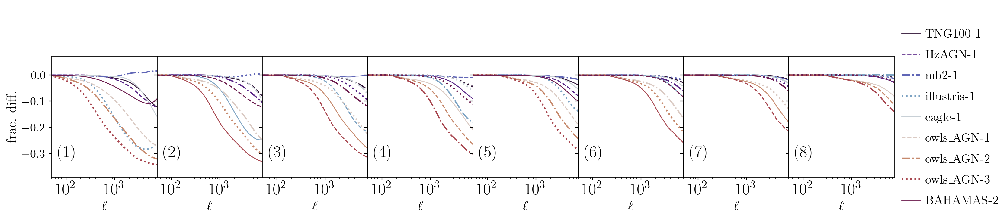

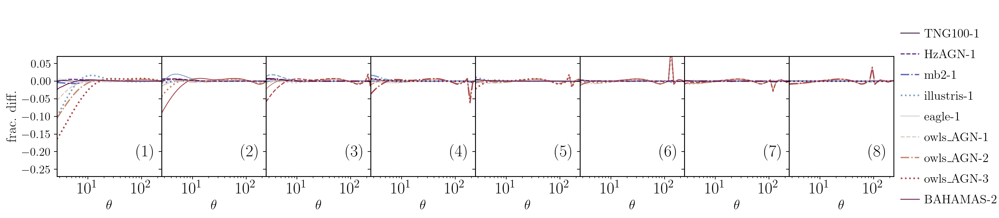

In [38]:
matplotlib.rcParams['legend.fontsize'] = 15
cnu.plot_C_gg_tomo(ell=ell,
                   C_gg=C_gg,
                   C_gg_ref=C_gg_ref,
                   lmin=50,
                   lmax=ell[len(ell)-1],
                   cmap="twilight_shifted",
                   bintextpos = [0.15, 0.2],
                   ylim = [0.61,1.07],
                   legend = param,
                   legendloc=(0.9,0.05),
                   linewidth=[1.0, 1.3, 1.6, 1.9],
                   linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                   figsize = (18, 13./5),
                   bintextsize = 20,
                   yaxislabelsize = 17,
                   yaxisticklabelsize = 14,
                   xaxisticklabelsize = 20)
cnu.plot_wtheta_tomo(theta_wtheta=wtheta_theta,
                     theta_wtheta_ref=wtheta_theta_ref,
                     cmap="twilight_shifted",
                     bintextpos = [0.85, 0.2],
                     ylim = [0.73,1.07],
                     legend = param,
                     legendloc=(0.9,0.05),
                     linewidth=[1.0, 1.3, 1.6, 1.9],
                     linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                     figsize = (18, 13./5),
                     bintextsize = 20,
                     yaxislabelsize = 17,
                     yaxisticklabelsize = 14,
                     xaxisticklabelsize = 20)

## Check how CAMB and CosmoLike accuracy settings change $C_\ell^{gg}$ and $w(\theta)$

The $C_\ell^{gg}$ sweep uses $x$ from 0.6 to 5.6: `CAMBAccuracyBoost`
$=1+x/3$, `CLAccuracyBoost` $=1+x$ and `CLIntegrationAccuracy`
$=\lfloor x\rfloor$, relative to the default settings, in a ±1.5% band. The
$w(\theta)$ sweep, in 80 angular bins and a ±2.5% band, starts both the
sweep and its reference from `CAMBAccuracyBoost` $=1.2$ instead of 1; the
comment in that cell records that $w(\theta)$ needs this CAMB setting.

In [39]:
ell = np.arange(10., 8500., 30.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(0.6,6.0,0.5)
C_gg = []
for x in param:
    C_gg.append(nw.C_gg_tomo(ell=ell,limber=False,AccuracyBoost=1,CAMBAccuracyBoost=1.+x/3,CLAccuracyBoost=1+x,CLIntegrationAccuracy=int(x)))
    
# Plot the Ratio over ref cosmology
C_gg_ref = nw.C_gg_tomo(ell=ell,limber=False,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0)

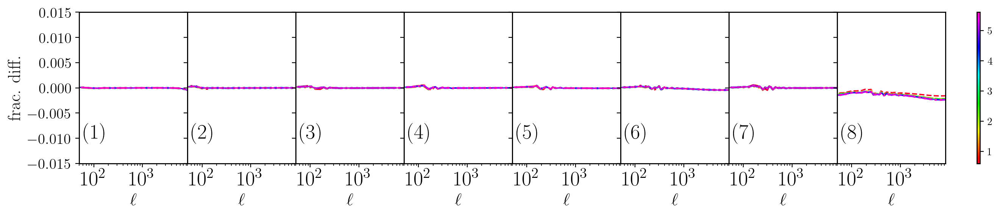

In [40]:
matplotlib.rcParams['legend.fontsize'] = 15
cnu.plot_C_gg_tomo(ell=ell,
                   C_gg=C_gg,
                   C_gg_ref=C_gg_ref,
                   lmin=50,
                   lmax=ell[len(ell)-1],
                   bintextpos = [0.15, 0.2],
                   ylim = [0.985,1.015],
                   param = param,
                   legendloc = (0.9,0.05),
                   linewidth =[1.0, 1.3, 1.6, 1.9],
                   linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                   figsize = (18, 13./5),
                   bintextsize = 20,
                   yaxislabelsize = 17,
                   yaxisticklabelsize = 14,
                   xaxisticklabelsize = 20,
                   rescale=1,
                   ydecades=4)

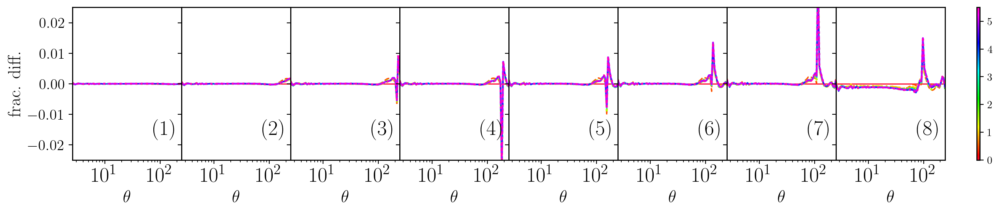

In [41]:
# w(theta) needs CAMBAccuracyBoost = 1.2, so the sweep and its
# reference start from that value.
param = np.arange(0,6.0,0.5)

wtheta_theta = []
for x in param:
    wtheta_theta.append(nw.w_theta(ntheta=80,AccuracyBoost=1,CAMBAccuracyBoost=1.2+x/3,CLAccuracyBoost=1.0+x,CLIntegrationAccuracy=int(x)))
wtheta_theta_ref = nw.w_theta(ntheta=80,AccuracyBoost=1,CAMBAccuracyBoost=1.2,CLAccuracyBoost=1.0,CLIntegrationAccuracy=0)
  
cnu.plot_wtheta_tomo(theta_wtheta = wtheta_theta,
                     theta_wtheta_ref = wtheta_theta_ref,
                     ylim = [0.975,1.025],
                     bintextpos = [0.85, 0.2],
                     param = param,
                     legendloc=(0.9,0.05),
                     linewidth =[1.0, 1.3, 1.6, 1.9],
                     linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                     figsize = (18, 13./5),
                     bintextsize = 20,
                     yaxislabelsize = 17,
                     yaxisticklabelsize = 14,
                     xaxisticklabelsize = 20)

## Compute $\chi^2$ of the Roman 3x2pt likelihood

`nw.init_cosmolike(CLprobe="3x2pt", with_data=True)` selects $\xi_\pm$,
$\gamma_t$ and $w$, installs the galaxy-bias model, and loads the data vector
[data/example1.modelvector](data/example1.modelvector) (a noiseless
synthetic vector computed without baryonic feedback), the covariance
[data/example1_cov](data/example1_cov) and the mask
[data/example1.mask](data/example1.mask). `nw.get_chi2` computes the theory
vector $t$, which keeps all 2,115 positions with the masked entries set to
zero, and
$$\chi^2=\sum_{ij}(d-t)_i\,(C^{-1})_{ij}\,(d-t)_j$$
over the 1,950 retained entries, with $d$ the stored data vector and $C$ the
covariance. The stored output gives $\chi^2=0.506$ at the fiducial point;
`cobaya-run` on [EXAMPLE_EVALUATE2.yaml](EXAMPLE_EVALUATE2.yaml) evaluates
the same point.

In [42]:
# Re-init with the chi2 machinery: probes, covariance, mask, and
# data vector (nw.init_cosmolike holds the full sequence; get_chi2
# lives in the wrappers module, call it as nw.get_chi2)
ini = nw.init_cosmolike(CLprobe="3x2pt", with_data=True)

[2026-10-01 14:26:59.599] [info] init_ntomo_powerspectra: GGL pair L6-S0 is excluded
[2026-10-01 14:26:59.599] [info] init_ntomo_powerspectra: GGL pair L7-S0 is excluded
[2026-10-01 14:26:59.599] [info] init_ntomo_powerspectra: GGL pair L7-S1 is excluded


In [43]:
print(rf"$\chi^2$={nw.get_chi2():3.3f}")

$\chi^2$=0.506


## How $\chi^2$ changes with the accuracy settings

The cell repeats the $\chi^2$ evaluation for $x$ from 0 to 5.5, with
`CAMBAccuracyBoost` $=1+x/3$, `CLAccuracyBoost` $=1+x$ and
`CLIntegrationAccuracy` $=\lfloor x\rfloor$, and plots
$\Delta\chi^2=\chi^2(x)-\chi^2(5.5)$ against $x$ (the plot carries no axis
labels). The value at $x=0$ is the error of the default settings relative
to the most accurate run; the project's reference tests accept
$|\Delta\chi^2|<0.2$.

In [44]:
param = np.arange(0,6,0.5)      
chi2 = []
for x in param:
    chi2.append(nw.get_chi2(AccuracyBoost=1,CAMBAccuracyBoost=1.+x/3,CLAccuracyBoost=1+x,CLIntegrationAccuracy=int(x)))
chi2 = np.array(chi2)

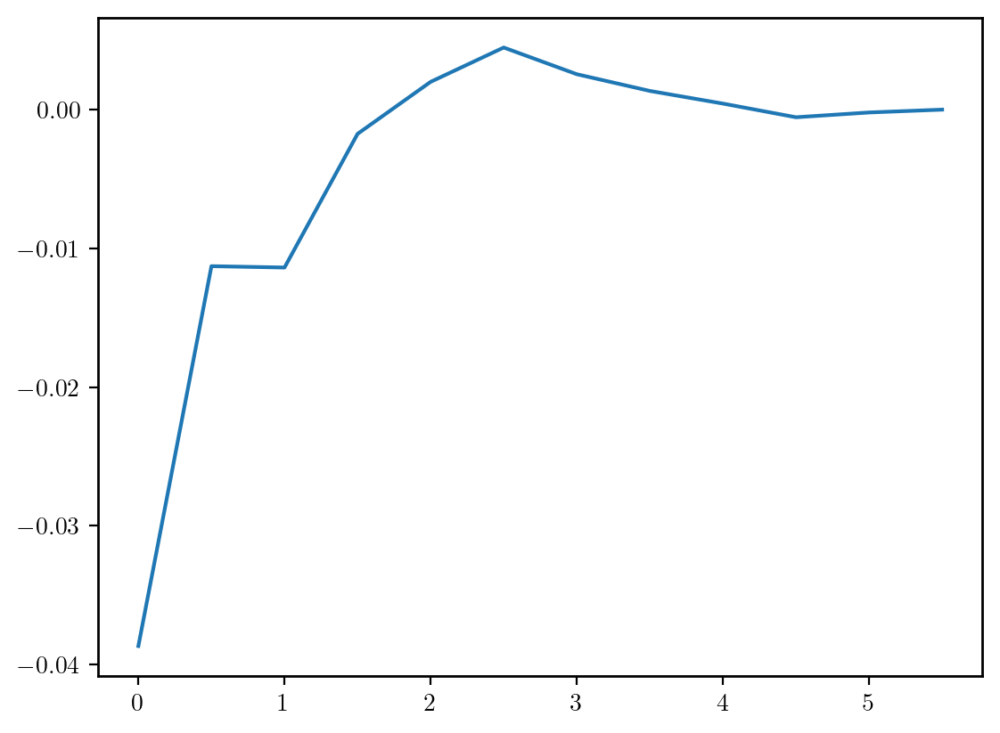

In [45]:
plt.plot(param, np.array(chi2-chi2[-1]))

## Compare halofit with EuclidEmulator2

`non_linear_emul=2` takes the nonlinear matter power spectrum from CAMB's
halofit fit (the Takahashi et al. 2012 version), the default here;
`non_linear_emul=1` multiplies the linear spectrum by the EuclidEmulator2
boost, emulated from N-body simulations. The first cell prints $\chi^2$ for
both against the data vector, which was made with halofit:
$\chi^2=99.3$ for EE2 and $0.506$ for halofit in the stored output. The
figure shows $w(\theta)$ with halofit relative to EE2,
$w^{\rm halofit}/w^{\rm EE2}-1$, in 80 angular bins and a ±10% band, both
at `CAMBAccuracyBoost` = 1.2.

In [46]:
print(rf"$\chi^2$={nw.get_chi2(non_linear_emul=1):3.3f}")
print(rf"$\chi^2$={nw.get_chi2(non_linear_emul=2):3.3f}")

/Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/.local/lib/python3.11/site-packages/euclidemu2/ee2_bindata.dat
$\chi^2$=99.261


$\chi^2$=0.506


In [47]:
# Both predictions use CAMBAccuracyBoost = 1.2, the w(theta) setting
# of the accuracy section. The curve uses halofit (non_linear_emul=2)
# and the reference EuclidEmulator2 (non_linear_emul=1).
param = [1]
wtheta_theta = []
for x in param:
    wtheta_theta.append(nw.w_theta(ntheta=80,AccuracyBoost=1,CAMBAccuracyBoost=1.2,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=2))
wtheta_theta_ref = nw.w_theta(ntheta=80,AccuracyBoost=1,CAMBAccuracyBoost=1.2,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=1)

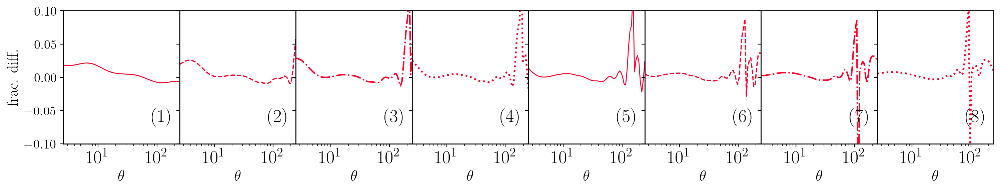

In [48]:
cnu.plot_wtheta_tomo(theta_wtheta=wtheta_theta,
                     theta_wtheta_ref=wtheta_theta_ref,
                     ylim = [0.9,1.1],
                     bintextpos = [0.85, 0.2],
                     param = param,
                     legendloc=(0.9,0.05),
                     linewidth=[1.0, 1.3, 1.6, 1.9],
                     linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                     figsize = (18, 13./5),
                     bintextsize = 20,
                     yaxislabelsize = 17,
                     yaxisticklabelsize = 14,
                     xaxisticklabelsize = 20,
                     colorbar=None)